# Table of contents

**1. Installation & setup**
   - Install bombcell package
   - Import libraries and set up paths
   - Configure parameters for both quality metrics and ephys properties

**2. Quality metrics analysis**
   - Run bombcell quality control pipeline
   - Classify units (good/MUA/noise/non-somatic)
   - Explore quality metrics results
   - Use interactive GUI for manual validation
   - Fine-tune classification parameters

**3. Ephys properties & cell classification** 
   - Compute electrophysiological properties (firing patterns, waveform features, etc.)
   - Classify cell types (cortical: pyramidal/interneurons, striatal: MSN/FSI/UIN)
   - Generate classification plots and results

---

# 1. Installation & setup

#### Install bombcell

To install the latest stable version:
```bash
conda create -n bombcell python=3.11
conda activate bombcell
pip install uv
uv pip install bombcell # you could do `pip install .`, but uv is much quicker!
```
To install the dev version (with the latest updates): 
```bash
conda create -n bombcell python=3.11
conda activate bombcell
git clone https://github.com/Julie-Fabre/bombcell.git
cd bombcell/pyBombCell
pip install uv
uv pip install -e .
```

#### Import libraries

In [1]:
import os, sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

import bombcell as bc

✅ ipywidgets available - interactive GUI ready


In [2]:
# Optional

# # Add bombcell to Python path if NOT installed with pip
# # If notebook is running in bombcell repo:
# demo_dir = Path(os.getcwd())
# pyBombCell_dir = demo_dir.parent
# # Else:
# # pyBombCell_dir = "path/to/bombcell/repository/root"
# sys.path.append(str(pyBombCell_dir))

#### Define paths

In [5]:
# Replace with your kilosort directory
ks_dir = "/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4"

# Set bombcell's output directory
save_path = Path(ks_dir) / "bombcell"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4


# Section 1: Quality Metrics

In [7]:
## For Neuropixels probes, provide raw and meta files
## Leave 'None' if no raw data. Ideally, your raw data is common-average-referenced and
# the channels are temporally aligned to each other (this can be done with CatGT)
raw_file_path =  "/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/rat17_ap3000_ml4600_dv1600_B4_g0_t0.imec0.ap.bin" #None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0_bc_decompressed.imec0.ap.bin" # ks_dir
meta_file_path = "/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/rat17_ap3000_ml4600_dv1600_B4_g0_t0.imec0.ap.meta" #None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0_bc_decompressed.imec0.ap.bin"None#"/home/julie/Dropbox/Example datatsets/JF093_2023-03-09_site1/site1/2023-03-09_JF093_g0_t0.imec0.ap.meta"
## Get default parameters - we will see later in the notebook how to assess and fine-tune these
param = bc.get_default_parameters(ks_dir, 
                                  raw_file=raw_file_path,
                                  meta_file=meta_file_path,
                                  kilosort_version=4)

print("Bombcell parameters:")
pprint(param)

Bombcell parameters:
{'computeDistanceMetrics': False,
 'computeDrift': False,
 'computeSpatialDecay': True,
 'computeTimeChunks': False,
 'confidence_threshold': 0.9,
 'contamination_values': None,
 'decompress_data': False,
 'deltaTimeChunk': 360,
 'detrendForUnitMatch': False,
 'detrendWaveform': True,
 'driftBinSize': 60,
 'duplicateSpikeWindow_s': 3.4e-05,
 'ephysKilosortPath': '/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4',
 'ephys_meta_file': '/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/rat17_ap3000_ml4600_dv1600_B4_g0_t0.imec0.ap.meta',
 'ephys_sample_rate': 30000,
 'extractRaw': True,
 'gain_to_uV': 3.7841796875,
 'hillOrLlobetMethod': True,
 'isoDmin': 20,
 'lratioMax': 0.3,
 'maxDrift': 100,
 'maxMainPeakToTroughRatio_nonSomatic': 0.8,
 'maxNPeaks': 2,
 'maxNTroughs': 1,
 'maxPeak1ToPeak2Ratio_nonSomatic': 3,
 'maxPercSpikesMissing': 20,
 'maxRPVviolations': 0.1,
 'ma

##### Optionally, customize parameters (more on this later, below)

In [ ]:
# you might to change:

# 1. classification thresholds like: 
# param["maxRPVviolations"] = 0.1


#  2. or which quality metrics are computed (by default these are not): 
param["computeDistanceMetrics"] = 0
param["computeDrift"] = 0
param["splitGoodAndMua_NonSomatic"] = 0


#  3. how quality metrics are calculated:

# a. Refractory period violation (RPV) method - choose one of:
#    'hill' (default): Hill et al. method
#    'llobet': Llobet et al. method  
#    'ibl_sliding': IBL sliding RP method (sweeps tauR values with confidence-based estimation)
param["rpv_method"] = "hill"

# b. Refractory period values to test (in seconds)
#    For a single value: np.array([0.002])
#    For sweeping multiple values (recommended for ibl_sliding):
import numpy as np
param["tauR_values"] = np.arange(0.0005, 0.005, 0.0005)  # 0.5ms to 5ms in 0.5ms steps

# c. Censored period (in seconds) - ISIs below this are excluded as duplicates
param["tauC"] = 0.0001  # 0.1ms

# d. For ibl_sliding method only:
# param["contamination_values"] = None  # Uses default 0.5% to 35%
# param["confidence_threshold"] = 0.9  # 90% confidence threshold

# e. Or whether the recording is split into time chunks to determine "good" time chunks: 
# param["computeTimeChunks"] = 0

# full list in the wiki or in the bc.get_default_parameters function

🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4
Results will be saved to: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell

Loading ephys data...
Loaded ephys data: 357 units, 908,460 spikes

🔍 Extracting raw waveforms...


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   22.7s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   31.4s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:   43.1s
[Parallel(n_jobs=-1)]: Done  31 tasks      | elapsed:   54.1s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done  60 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  71 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 127 tasks      | elapsed:  9.1min
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed: 10.1min
[Paralle


⚙️ Computing quality metrics for 357 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/357 units


Saving GUI visualization data...
GUI visualization data saved to: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell/for_GUI/gui_data.pkl
   Generated spatial decay fits: 357/357 units
   Generated amplitude fits: 355/357 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


/home/cxp8326/.conda/envs/bombcell/lib/python3.11/site-packages/bombcell/plot_functions.py:455: RuntimeWarning: Could not create non-soma upset plot due to library compatibility: Buffer dtype mismatch, expected 'Python object' but got 'bool'
  warnings.warn(f"Could not create {unit_type_str.lower()} upset plot due to library compatibility: {e}", RuntimeWarning)


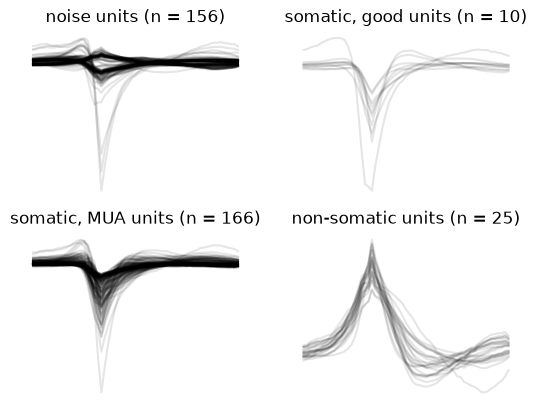

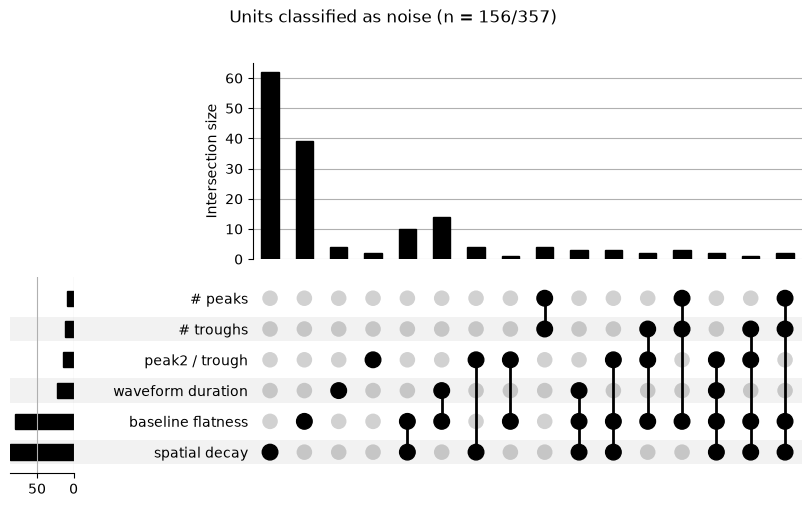

<Figure size 640x480 with 0 Axes>

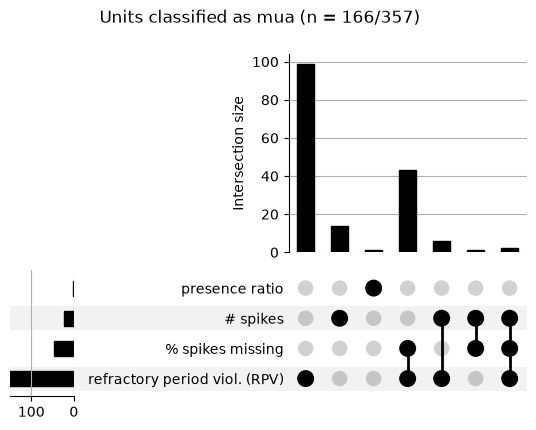

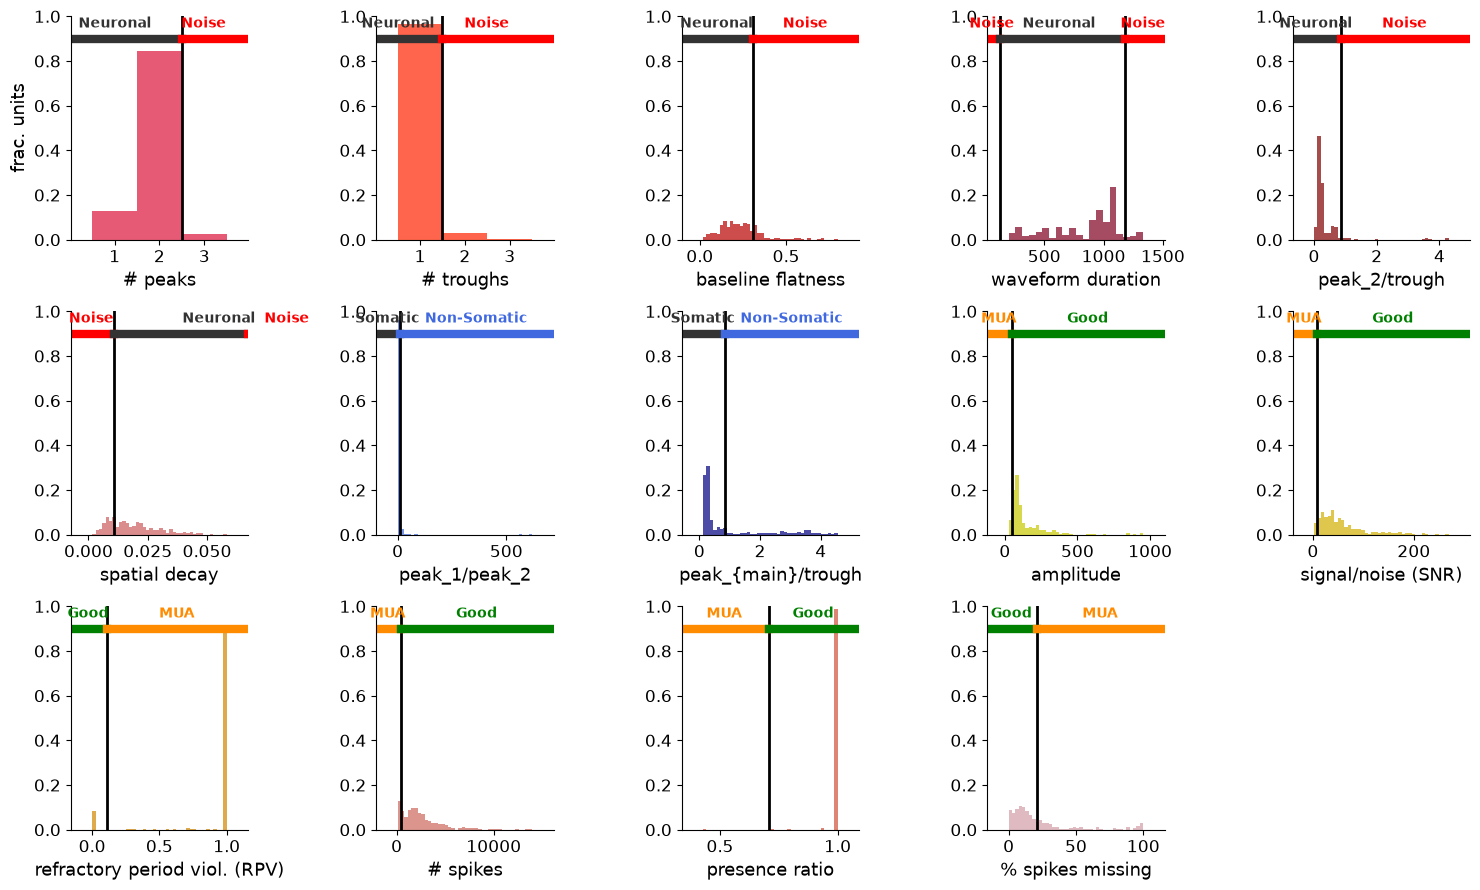


Saving results...
📁 Saving TSV files to Kilosort directory: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4
All expected metrics were successfully saved.


In [8]:
(
    quality_metrics,
    param,
    unit_type,
    unit_type_string,
) = bc.run_bombcell(
    ks_dir, save_path, param
)
# Use the output summary plots (below) to see if the 
# quality metric thresholds seem roughly OK for your 
# data (i.e. there isn't one threshold removing all 
# units or a threshold may below that removes none)
# more details on these output plots in the wiki:
# https://github.com/Julie-Fabre/bombcell/wiki/Summary-output-plots

##### How to access bombcell's saved quality metrics
Looking at all quality metric values per unit: 

In [9]:
# quality metric values
quality_metrics_table = pd.DataFrame(quality_metrics)
quality_metrics_table.insert(0, 'Bombcell_unit_type', unit_type_string)
quality_metrics_table

,Bombcell_unit_type,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,MUA,0,2422.0,2.0,1.0,1000.000000,0.030543,0.178272,0.134206,0.185085,...,NaN,NaN,84.594406,58.167243,NaN,NaN,NaN,0.0335,844.3166,3
1,NON-SOMA,1,4720.0,2.0,1.0,1066.666667,0.011042,0.203944,0.642931,3.669531,...,NaN,NaN,48.213871,26.468095,NaN,NaN,NaN,0.0335,844.3166,2
2,MUA,2,138.0,2.0,1.0,1100.000000,0.034988,0.175730,0.212976,0.212976,...,NaN,NaN,344.603872,62.138029,NaN,NaN,NaN,0.0335,844.3166,3
3,MUA,3,967.0,2.0,1.0,266.666667,0.042932,0.050234,0.218781,0.292077,...,NaN,NaN,221.896753,228.424762,NaN,NaN,NaN,0.0335,844.3166,3
4,MUA,4,9790.0,2.0,1.0,633.333333,0.016505,0.145711,0.105366,0.145711,...,NaN,NaN,85.182517,34.232953,NaN,NaN,NaN,0.0335,844.3166,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,NOISE,352,2174.0,2.0,1.0,900.000000,0.007202,0.252564,0.233350,0.252564,...,NaN,NaN,37.446097,29.507178,NaN,NaN,NaN,0.0335,844.3166,360
353,NOISE,353,933.0,1.0,1.0,533.333333,0.007227,0.159149,0.188259,3.712313,...,NaN,NaN,41.913922,9.637238,NaN,NaN,NaN,0.0335,844.3166,367
354,NON-SOMA,354,312.0,1.0,1.0,533.333333,0.012628,0.112711,0.116877,1.977833,...,NaN,NaN,35.653677,15.241839,NaN,NaN,NaN,0.0335,844.3166,369
355,NOISE,355,1192.0,2.0,1.0,1300.000000,0.003212,0.491293,2.035445,2.035445,...,NaN,NaN,26.158017,22.404169,NaN,NaN,NaN,0.0335,844.3166,377


In [10]:
# boolean table, if quality metrics pass threshold given parameters
boolean_quality_metrics_table = bc.make_qm_table(
    quality_metrics, param, unit_type_string
)
boolean_quality_metrics_table

,unit_type,Original ID,# peaks,# troughs,waveform duration,baseline flatness,peak2 / trough,spatial decay,% spikes missing,presence ratio,# spikes,fraction RPVs,amplitude,SNR,trough / peak2,peak1 / peak2
0,MUA,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,NON-SOMA,1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,MUA,2,False,False,False,False,False,False,False,False,True,True,False,False,False,False
3,MUA,3,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,MUA,4,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,NOISE,352,False,False,False,False,False,True,False,False,False,False,False,False,False,False
353,NOISE,353,False,False,False,False,False,True,False,False,False,False,False,False,False,False
354,NON-SOMA,354,False,False,False,False,False,False,False,False,False,False,False,False,True,False
355,NOISE,355,False,False,True,True,True,True,False,False,False,False,False,False,False,False


Example: get all quality metrics for unit 12

In [11]:
u = 12

units = quality_metrics_table.phy_clusterID
quality_metrics_table.loc[units == u, :]

,Bombcell_unit_type,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,scndPeakToTroughRatio,mainPeakToTroughRatio,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
12,NOISE,12,1600.0,2.0,1.0,1100.0,0.005448,0.151619,0.557952,2.05278,...,NaN,NaN,92.710982,137.600586,NaN,NaN,NaN,0.0335,844.3166,17


#### Look at your data and bombcell's metrics in the minimal GUI

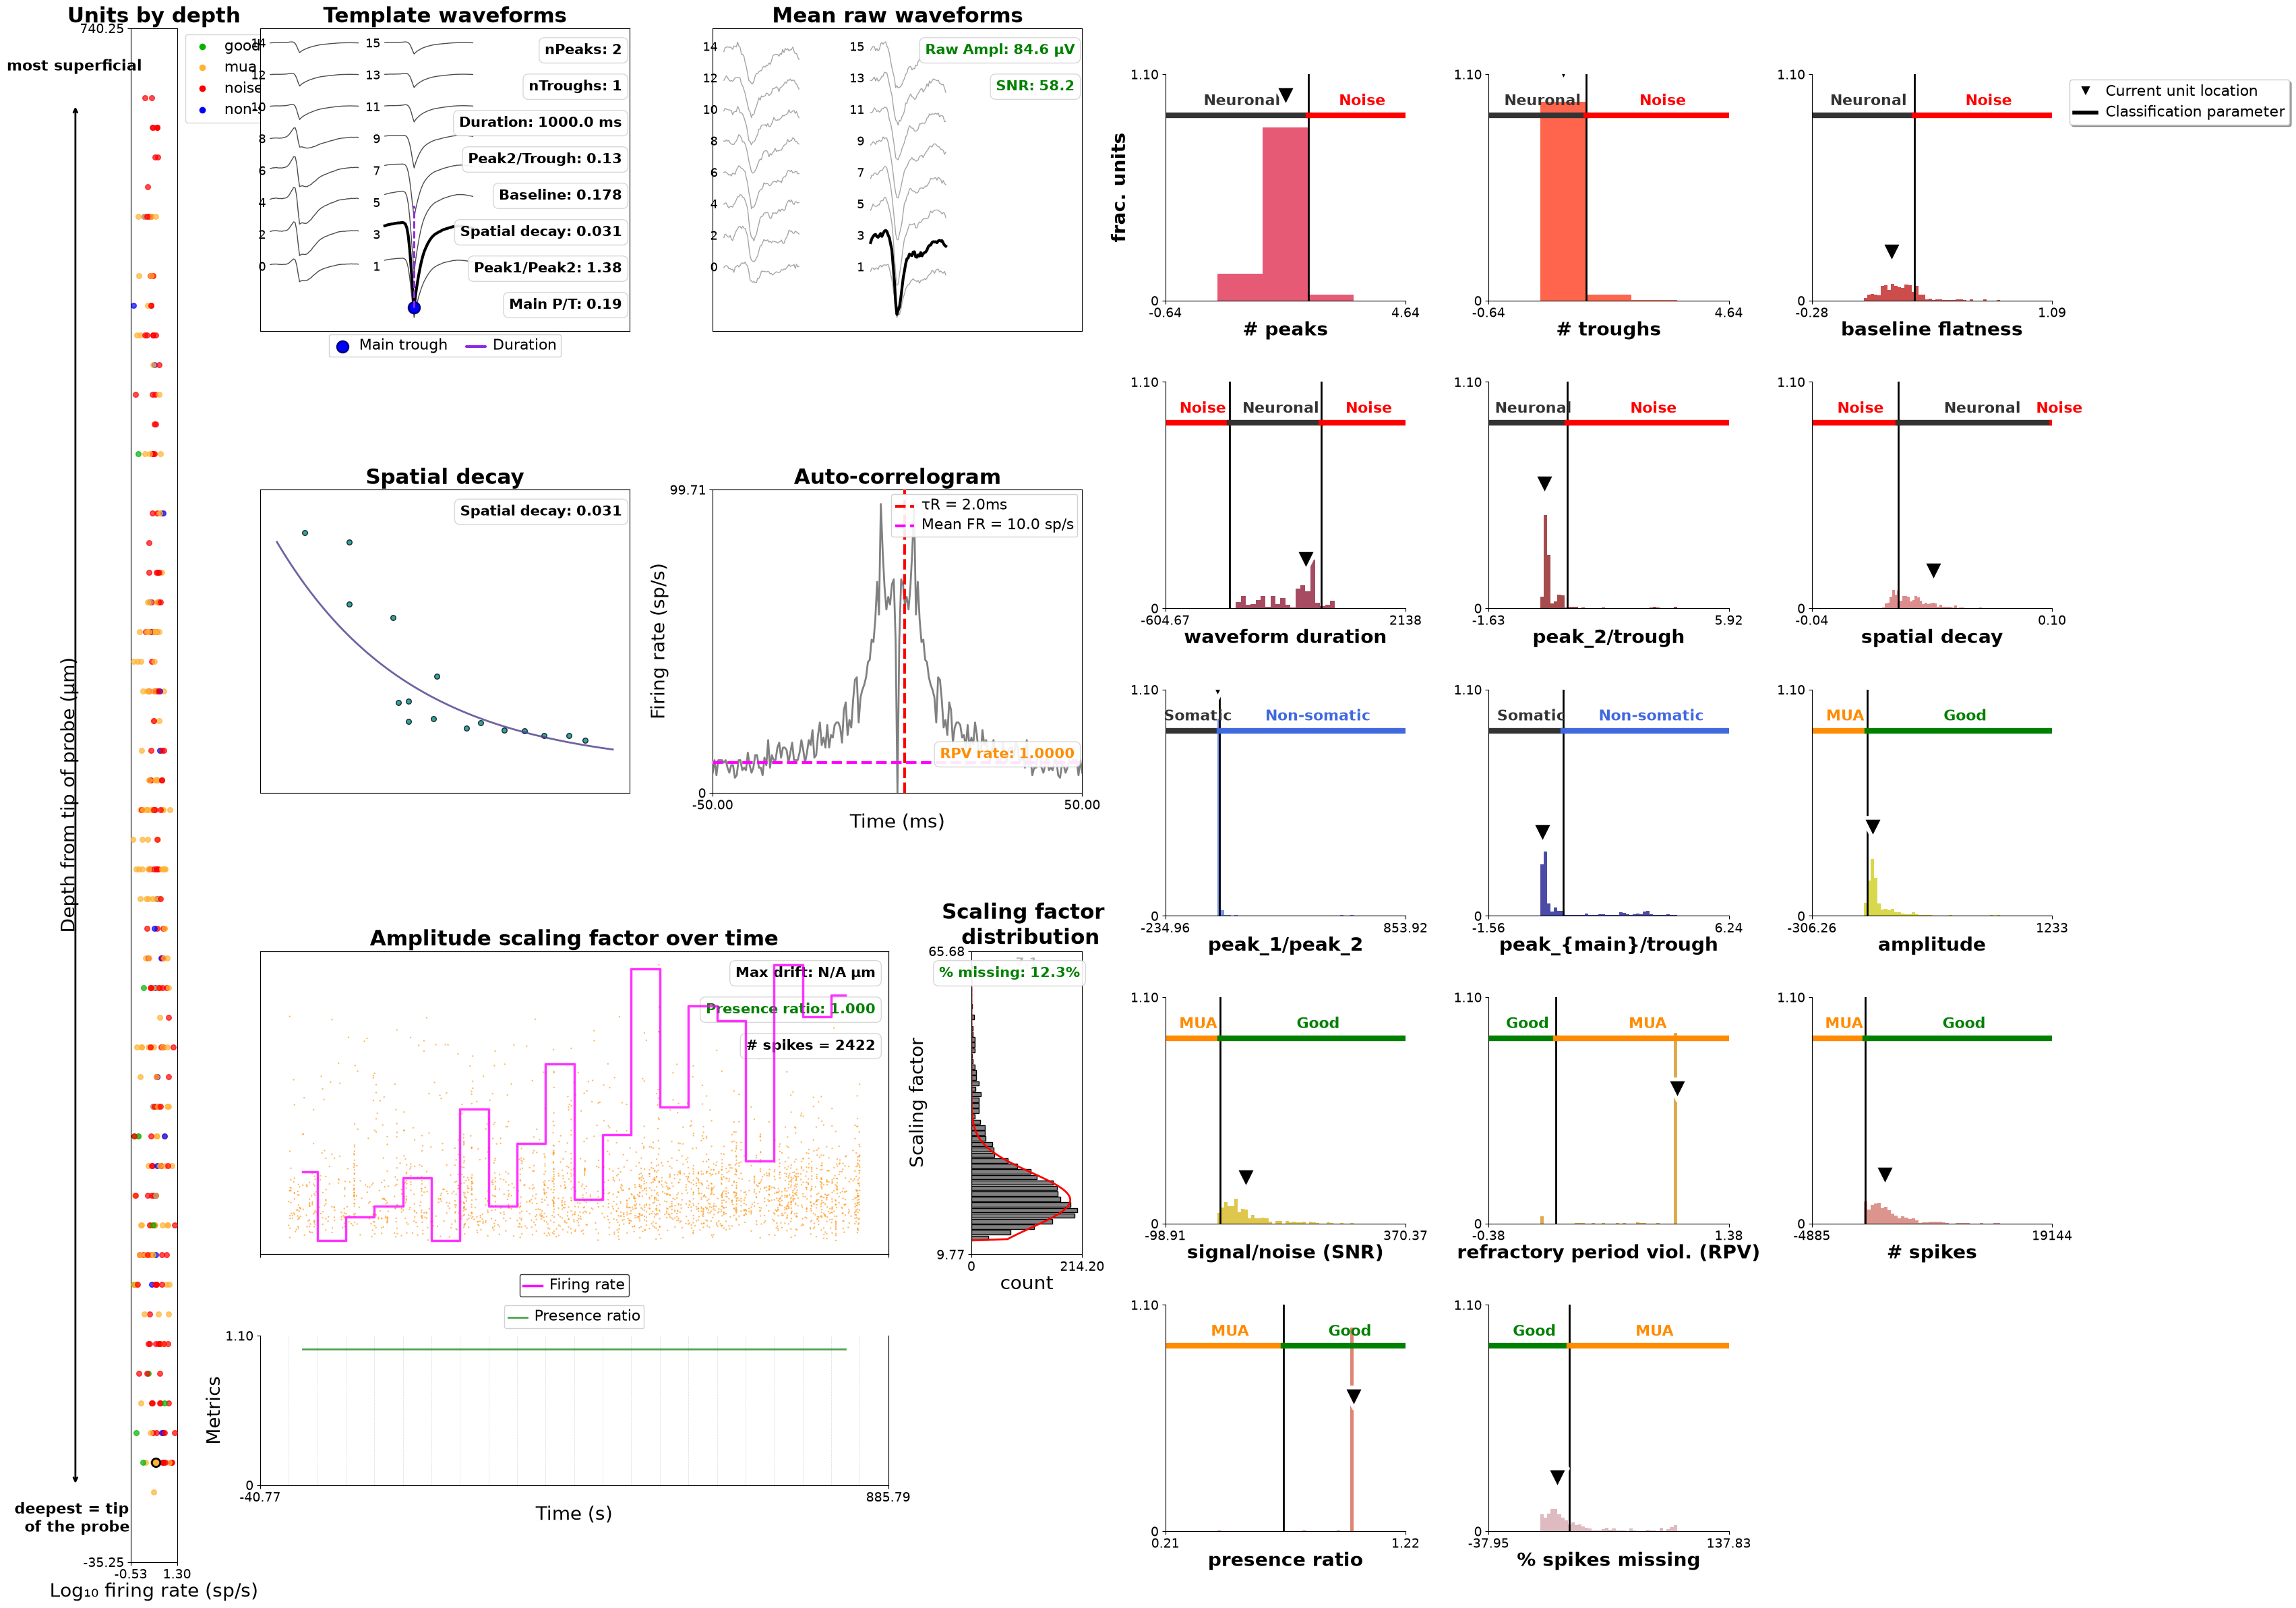

In [12]:
# Launch minimal GUI.
# Ideally, take a look at your units for a few datasets so you can get an idea of which 
# parameters will work best for your purposes. 
gui = bc.unit_quality_gui(
    ks_dir=ks_dir,
    quality_metrics=quality_metrics,
    unit_types=unit_type,
    param=param,
    save_path=save_path,
)

In [13]:
# Compare manual vs BombCell classifications (only requires save_path)
bc.compare_manual_vs_bombcell(save_path)

📊 Comparing manual vs BombCell classifications from: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell
✅ Loaded BombCell results: 357 units
❌ No manual classifications found. Please use the GUI to manually classify some units first.
Expected file: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell/manual_unit_classifications.csv
❌ No manual classifications found.
   Use the GUI to manually classify some units first:
   bc.unit_quality_gui(ks_dir, quality_metrics, unit_types, param, save_path)


#### Fine-tune quality metric thresholds 
Based on bombcell's global output plots, looking through the GUI, your knowledge of neurons in your brain region and bombcell's suggestions above, you can adjust any of bombcell's quality metric thresholds and which quality metrics are computed.
For instance, if you are recording in the cerebellum and want to keep complex spikes, you might want to tweak waveform paramaters like max number of peaks and troughs to ensure you aren't classifying these units as noise. 

/home/cxp8326/.conda/envs/bombcell/lib/python3.11/site-packages/bombcell/plot_functions.py:455: RuntimeWarning: Could not create non-soma upset plot due to library compatibility: Buffer dtype mismatch, expected 'Python object' but got 'bool'
  warnings.warn(f"Could not create {unit_type_str.lower()} upset plot due to library compatibility: {e}", RuntimeWarning)


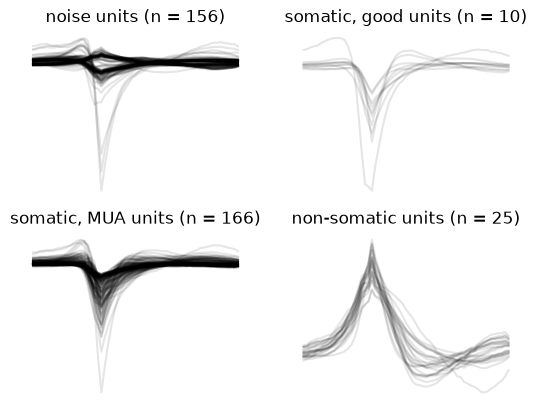

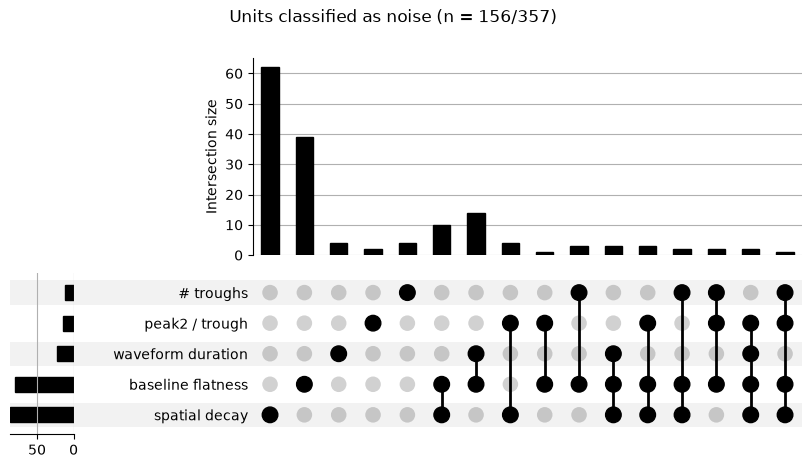

<Figure size 640x480 with 0 Axes>

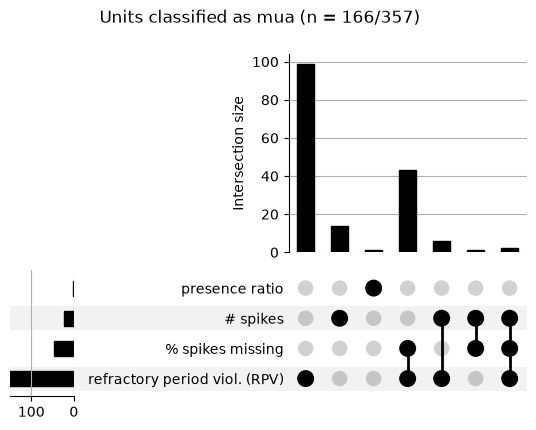

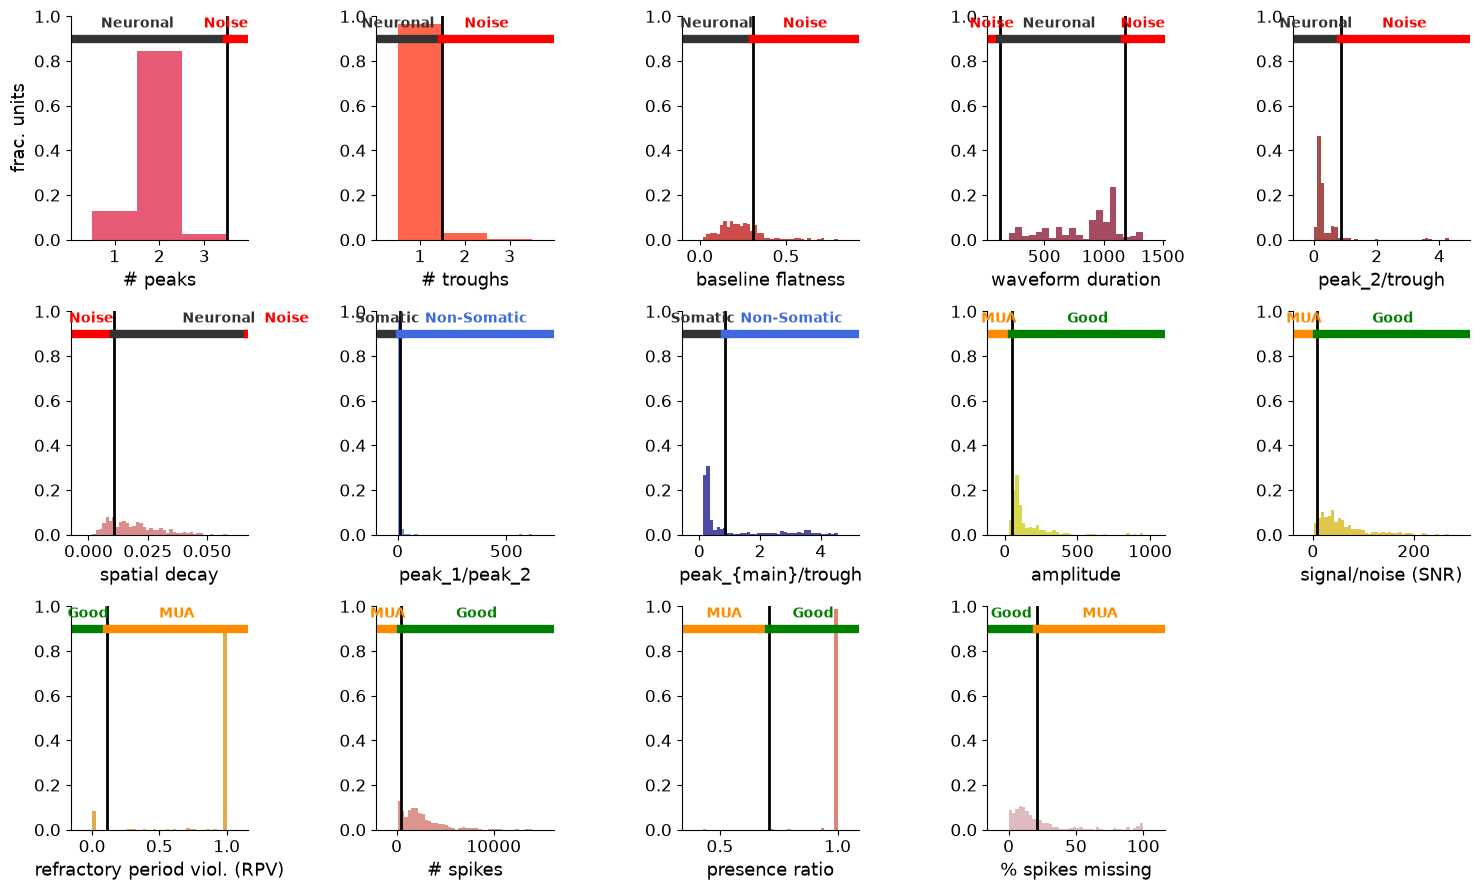

In [14]:
# Example: how to tweak a classification threshold and replot the summary plots 

# load previously computed quality metrics
param, quality_metrics, fractions_RPVs_all_taur = bc.load_bc_results(save_path)
# change parameter of interest 
param["maxNPeaks"] = 3 # for instance, it you more atypical waveform shapes in your region of interest
# get quality unit types
unit_type, unit_type_string = bc.qm.get_quality_unit_type(
        param, quality_metrics
    ) 
# load ephys data
(
    spike_times_samples,
    spike_clusters, # actually spike_templates, but they're the same in bombcell
    template_waveforms,
    template_amplitudes,
    pc_features,
    pc_features_idx,
    channel_positions,
) = bc.load_ephys_data(ks_dir)
# replot global output plots
bc.plot_summary_data(quality_metrics, template_waveforms, unit_type, unit_type_string, param)


# Section 2: Ephys Properties & Cell Classification

In [17]:
# Use the real dataset for ephys properties demonstration
ks_dir = "/gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4"
save_path = Path(ks_dir) / "bombcell"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4


In [18]:
# Compute ephys properties for cell type classification
ephys_param = bc.get_ephys_parameters(ks_dir)

# Compute all ephys properties - now defaults to ks_dir/bombcell
ephys_properties, ephys_param = bc.run_all_ephys_properties(ks_dir, ephys_param, save_path=save_path)

Computing ephys properties for 357 units ...


Computing ephys properties:   0%|          | 0/357 [00:00<?, ?it/s]

Ephys properties computation complete!
Ephys properties saved to: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell/templates._bc_ephysProperties.parquet
Parameters saved to: /gpfs/projects/p52962/rat17_ap3000_ml4600_dv1600_B4_g0/rat17_ap3000_ml4600_dv1600_B4_g0_imec0/kilosort4/bombcell/_bc_ephysParameters.parquet


Classifying cortex neurons...


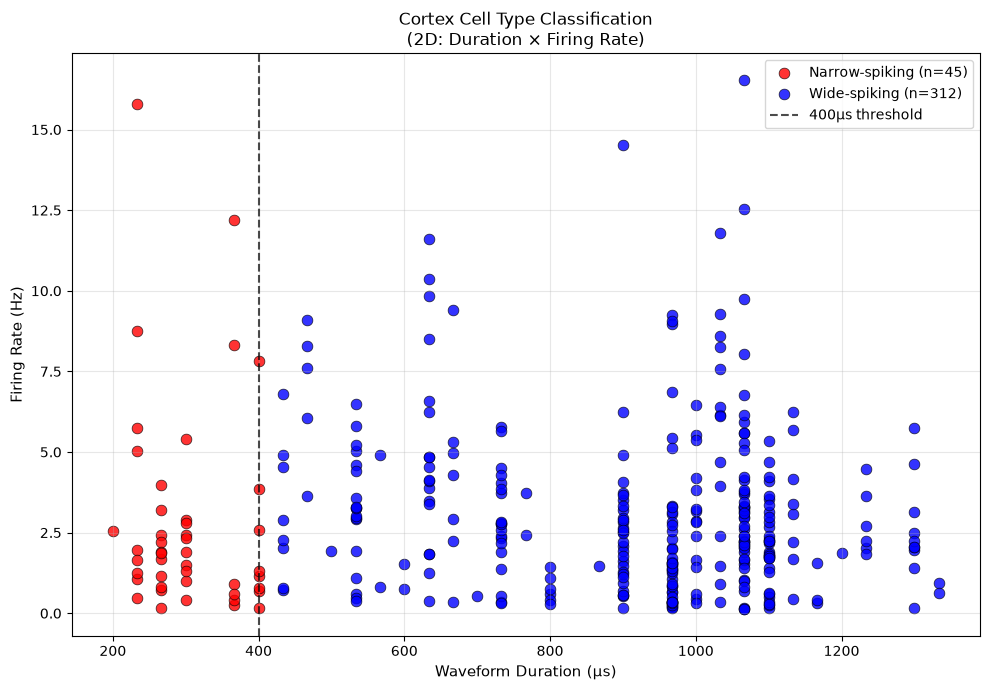

Plotted 357 units:
  Waveform duration range: 200-1333 μs
  Firing rate range: 0.1-16.5 Hz

Cortex cell type distribution:
  Wide-spiking: 312 (87.4%)
  Narrow-spiking: 45 (12.6%)
  Unknown: 0 (0.0%)


In [19]:
# Cell type classification with automatic plot generation
# Specify brain region: 'cortex' or 'striatum'
brain_region = 'cortex'  # Change this to 'cortex' for cortical data. Striatum and cortex are the only two options for now. 

print(f"Classifying {brain_region} neurons...")
cell_types = bc.classify_and_plot_brain_region(ephys_properties, ephys_param, brain_region)

In [20]:
# Show classification results
if cell_types is not None:
    # Create combined results table
    ephys_df = pd.DataFrame(ephys_properties)
    ephys_properties_table = ephys_df.copy()
    ephys_properties_table['cell_type'] = cell_types
   
    print(ephys_properties_table)

     unit_id  postSpikeSuppression  acg_tau_rise  acg_tau_decay    isi_cv  \
0          0              4.487744           0.0      15.762842  1.922365   
1          1              4.803369           0.0      16.282026  2.178681   
2          2              0.000000           3.0       7.877245  1.693758   
3          3              2.174972           1.0       7.048477  1.861438   
4          4              4.688815           0.0      14.672498  2.640964   
..       ...                   ...           ...            ...       ...   
352      352              5.525546           0.0      21.385630  1.643505   
353      353              4.403587           0.0      11.310517  1.362074   
354      354              0.000000           0.0       4.241575  1.170065   
355      355              6.104118           0.0      15.839800  1.465550   
356      356              4.956258           0.0      11.596889  1.606265   

      isi_cv2  isi_skewness  prop_long_isi  waveform_duration_peak_trough  